**import library**

In [41]:
import pandas as pd
import numpy as np
import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

pd.options.mode.chained_assignment = None

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

**loading** dataset

In [42]:
df = pd.read_csv('C:\\Users\\Asus\Downloads\\analisis sentimen\\genshin_full_review.csv')

print("Jumlah data awal:", len(df))
df.head()

Jumlah data awal: 224524


,review,rating,date
0,seru banget njelajahin dunia dunia,5,2026-04-20 12:55:23
1,hoyo kenapa kamu jahat banget kenapa kamu ngas...,1,2026-04-20 12:55:04
2,bagus bgt,5,2026-04-20 11:26:37
3,oke lah,5,2026-04-20 09:17:33
4,"its getting worser and worser, worser quests, ...",1,2026-04-20 07:55:11


In [43]:
df.info()

print("\nMissing value:\n", df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 224524 entries, 0 to 224523
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   review  224524 non-null  str  
 1   rating  224524 non-null  int64
 2   date    224524 non-null  str  
dtypes: int64(1), str(2)
memory usage: 5.1 MB

Missing value:
 review    0
rating    0
date      0
dtype: int64


In [44]:
print("Jumlah data duplikat:", df.duplicated().sum())

df = df.dropna().drop_duplicates().reset_index(drop=True)

print("Jumlah data setelah cleaning awal:", len(df))

Jumlah data duplikat: 1
Jumlah data setelah cleaning awal: 224523


In [45]:
df = df.rename(columns={
    'review': 'ulasan',
    'rating': 'skor',
    'date': 'tanggal'
})

df.head()

,ulasan,skor,tanggal
0,seru banget njelajahin dunia dunia,5,2026-04-20 12:55:23
1,hoyo kenapa kamu jahat banget kenapa kamu ngas...,1,2026-04-20 12:55:04
2,bagus bgt,5,2026-04-20 11:26:37
3,oke lah,5,2026-04-20 09:17:33
4,"its getting worser and worser, worser quests, ...",1,2026-04-20 07:55:11


skor
5    161372
1     35596
4     13808
3      8539
2      5208
Name: count, dtype: int64


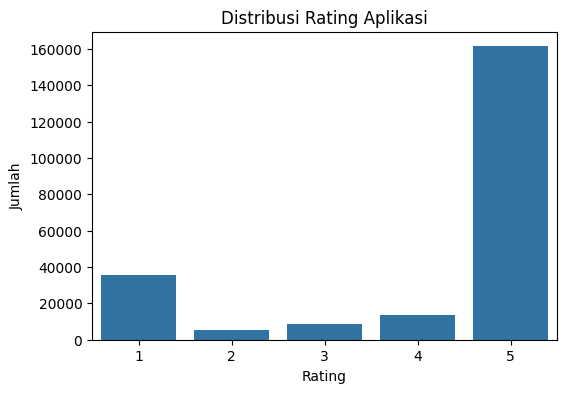

In [46]:
print(df['skor'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='skor', data=df)
plt.title('Distribusi Rating Aplikasi')
plt.xlabel('Rating')
plt.ylabel('Jumlah')
plt.show()

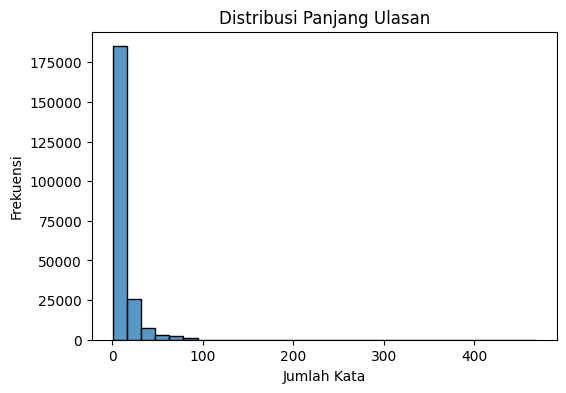

In [47]:
df['panjang_teks'] = df['ulasan'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(6,4))
sns.histplot(df['panjang_teks'], bins=30)
plt.title('Distribusi Panjang Ulasan')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.show()

**prepocessing**

In [48]:
slang_map = {
    'gk': 'tidak',
    'ga': 'tidak',
    'nggak': 'tidak',
    'bgt': 'banget',
    'bgus': 'bagus',
    'jelek': 'buruk',
    'apk': 'aplikasi',
    'lag': 'lambat',
    'ngelag': 'lambat',
    'mantap': 'bagus',
    'parah': 'sangat',
    'gampang': 'mudah',
    'dikit': 'sedikit',
    'udh': 'sudah',
    'skrg': 'sekarang',
    'tpi': 'tapi',
    'klo': 'kalau',
    'yg': 'yang',
    'dr': 'dari'
}

from nltk.corpus import stopwords

stopword_id = set(stopwords.words('indonesian'))
stopword_en = set(stopwords.words('english'))

extra_stopword = {
    'nya', 'sih', 'dong', 'nih', 'deh', 'loh', 'aja', 'ya'
}

stopword_all = stopword_id.union(stopword_en).union(extra_stopword)

In [49]:
negasi = {'tidak', 'bukan', 'kurang', 'jangan'}

stopword_all = stopword_all - negasi

def cleaning_pipeline(text):
    text = str(text).lower()
    
    text = re.sub(r'@\w+|#\w+', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    
    text = text.replace("tidak ", "tidak_")
    text = text.replace("bukan ", "bukan_")
    text = text.replace("kurang ", "kurang_")
    
    text = re.sub(r'\d+', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))

    text = re.sub(r'\s+', ' ', text).strip()
    
    tokens = text.split()
    
    tokens = [slang_map[word] if word in slang_map else word for word in tokens]
    tokens = [word for word in tokens if word not in stopword_all and len(word) > 2]
    
    if len(tokens) == 0:
        return None
    
    return " ".join(tokens)

In [50]:
jumlah_awal = len(df)

df['clean_text'] = df['ulasan'].apply(cleaning_pipeline)

df = df.dropna(subset=['clean_text']).reset_index(drop=True)

print("Jumlah sebelum preprocessing :", jumlah_awal)
print("Jumlah setelah preprocessing :", len(df))

Jumlah sebelum preprocessing : 224523
Jumlah setelah preprocessing : 219126


In [51]:
contoh = df[['ulasan', 'clean_text']].sample(5, random_state=42)

for i, row in contoh.iterrows():
    print(f"\nData ke-{i}")
    print("Asli  :", row['ulasan'])
    print("Bersih:", row['clean_text'])


Data ke-81137
Asli  : Saya ingin masuk dengan email saya tetapi salah , dan sudah coba ke 10 kali dengan lupa password tapi tidak bisa juga dengan tulisan password salah mohon segera diperbaiki ya
Bersih: masuk email salah coba kali lupa password tidakbisa tulisan password salah mohon diperbaiki

Data ke-175001
Asli  : I like this MUEHEHEHE
Bersih: like muehehehe

Data ke-89497
Asli  : Sebenarnya gamenya bagus tapi lain kali mihoyo untuk rate gacha-nya jangan kasih yang jelek terus lah
Bersih: gamenya bagus kali mihoyo rate gachanya jangan kasih buruk

Data ke-114633
Asli  : Gooddddddd games.....
Bersih: gooddddddd games

Data ke-204774
Asli  : Good
Bersih: good


pelabelan

In [52]:
import pandas as pd

pos_lex = pd.read_csv(
    'https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv',
    header=None
)

neg_lex = pd.read_csv(
    'https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv',
    header=None
)

positive_dict = dict(zip(pos_lex[0], pos_lex[1]))
negative_dict = dict(zip(neg_lex[0], neg_lex[1]))

negative_dict.update({
    'lambat': -2,
    'berat': -2,
    'lag': -2,
    'error': -3,
    'crash': -3,
    'bug': -2,
    'lemot': -2
})

positive_dict.update({
    'bagus': 2,
    'keren': 2,
    'mantap': 2,
    'smooth': 2
})

In [53]:
def hitung_sentimen(teks):
    skor = 0

    for kata in teks.split():
        skor += positive_dict.get(kata, 0)
        skor += negative_dict.get(kata, 0)

    if skor > 0:
        label = 'positif'
    elif skor < 0:
        label = 'negatif'
    else:
        label = 'netral'

    return skor, label

In [54]:
hasil = df['clean_text'].apply(hitung_sentimen)

df['score_sentimen'] = [h[0] for h in hasil]
df['label'] = [h[1] for h in hasil]

print(df['label'].value_counts())

label
positif    83473
negatif    81612
netral     54041
Name: count, dtype: int64


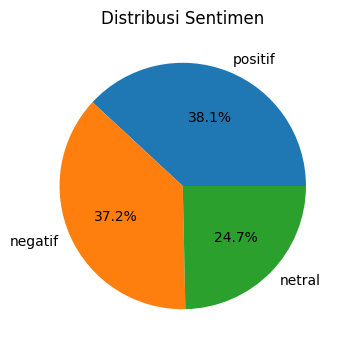

In [55]:
plt.figure(figsize=(6,4))
df['label'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribusi Sentimen')
plt.ylabel('')
plt.show()

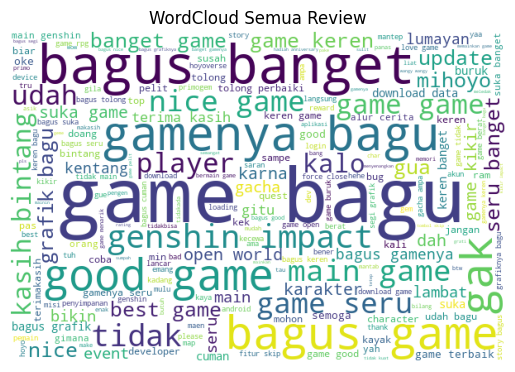

In [56]:
text_all = " ".join(df['clean_text'])

wc = WordCloud(width=600, height=400, background_color='white').generate(text_all)

plt.imshow(wc)
plt.axis('off')
plt.title('WordCloud Semua Review')
plt.show()

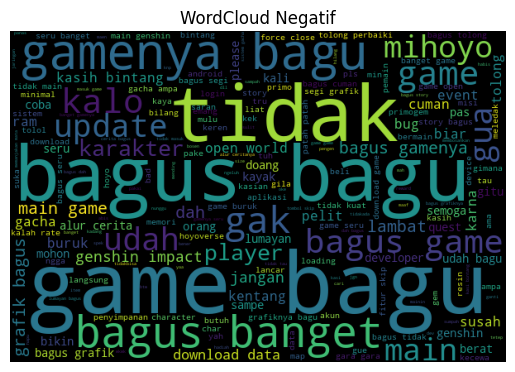

In [57]:
neg_text = " ".join(df[df['label']=='negatif']['clean_text'])

wc = WordCloud(width=600, height=400).generate(neg_text)

plt.imshow(wc)
plt.axis('off')
plt.title('WordCloud Negatif')
plt.show()

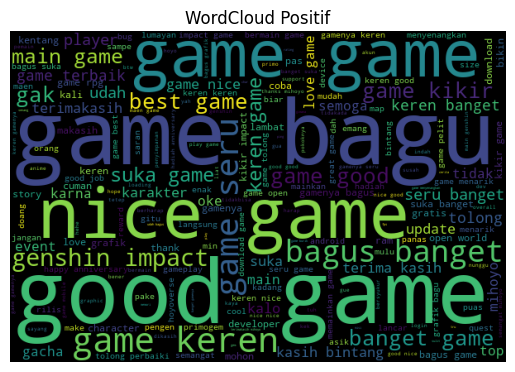

In [58]:
pos_text = " ".join(df[df['label']=='positif']['clean_text'])

wc = WordCloud(width=600, height=400).generate(pos_text)

plt.imshow(wc)
plt.axis('off')
plt.title('WordCloud Positif')
plt.show()

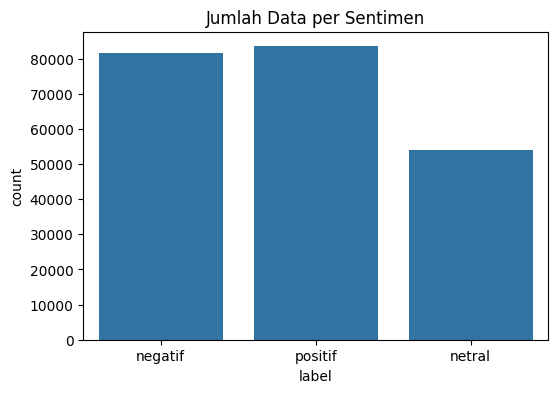

In [59]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title('Jumlah Data per Sentimen')
plt.show()

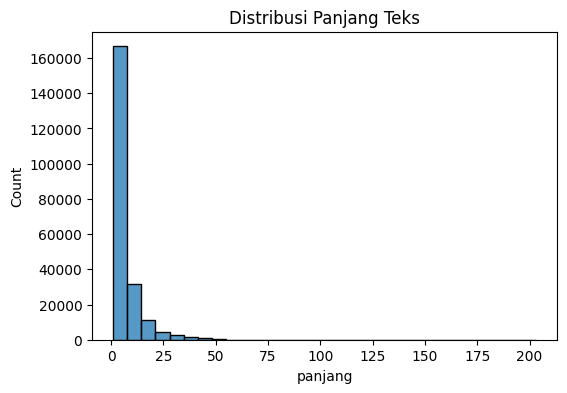

In [60]:
df['panjang'] = df['clean_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(6,4))
sns.histplot(df['panjang'], bins=30)
plt.title('Distribusi Panjang Teks')
plt.show()

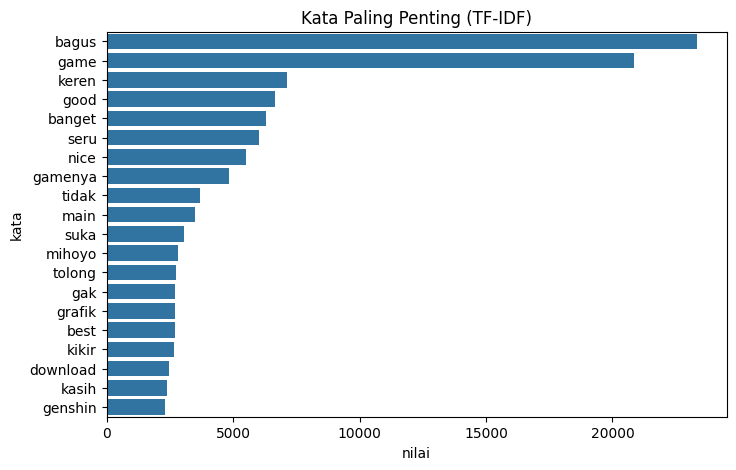

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer

vec = TfidfVectorizer(max_features=1000)
X = vec.fit_transform(df['clean_text'])

total = X.sum(axis=0)
kata = vec.get_feature_names_out()

tfidf_df = pd.DataFrame({
    'kata': kata,
    'nilai': total.A1
}).sort_values(by='nilai', ascending=False).head(20)

plt.figure(figsize=(8,5))
sns.barplot(x='nilai', y='kata', data=tfidf_df)
plt.title('Kata Paling Penting (TF-IDF)')
plt.show()

**modeling**

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

teks = df['clean_text'].astype(str)

label_dict = {'negatif': 0, 'netral': 1, 'positif': 2}
y = df['label'].map(label_dict)

tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1,2))
X = tfidf.fit_transform(teks)

Random Forest

In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_rf, y_train_rf)

pred_train_rf = rf.predict(X_train_rf)
pred_test_rf = rf.predict(X_test_rf)

print("=== RANDOM FOREST ===")
print("Train Acc :", accuracy_score(y_train_rf, pred_train_rf))
print("Test Acc  :", accuracy_score(y_test_rf, pred_test_rf))
print("F1 Score  :", f1_score(y_test_rf, pred_test_rf, average='macro'))
print(classification_report(y_test_rf, pred_test_rf))

=== RANDOM FOREST ===
Train Acc : 0.9946453779876356
Test Acc  : 0.9058814939213611
F1 Score  : 0.9065839641787857
              precision    recall  f1-score   support

           0       0.88      0.93      0.90     20403
           1       0.94      0.88      0.91     13510
           2       0.92      0.90      0.91     20869

    accuracy                           0.91     54782
   macro avg       0.91      0.90      0.91     54782
weighted avg       0.91      0.91      0.91     54782



SVM

In [64]:
from sklearn.svm import SVC

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

svm = SVC(kernel='linear', C=1)

svm.fit(X_train_svm, y_train_svm)

pred_train_svm = svm.predict(X_train_svm)
pred_test_svm = svm.predict(X_test_svm)

print("=== SVM ===")
print("Train Acc :", accuracy_score(y_train_svm, pred_train_svm))
print("Test Acc  :", accuracy_score(y_test_svm, pred_test_svm))
print("F1 Score  :", f1_score(y_test_svm, pred_test_svm, average='macro'))
print(classification_report(y_test_svm, pred_test_svm))

=== SVM ===
Train Acc : 0.9611637193382773
Test Acc  : 0.9468123944690366
F1 Score  : 0.9434759454201805
              precision    recall  f1-score   support

           0       0.94      0.96      0.95     16323
           1       0.94      0.90      0.92     10808
           2       0.96      0.96      0.96     16695

    accuracy                           0.95     43826
   macro avg       0.95      0.94      0.94     43826
weighted avg       0.95      0.95      0.95     43826



BilSTM

In [65]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report, f1_score
import numpy as np

token = Tokenizer(num_words=15000, oov_token="<OOV>")
token.fit_on_texts(teks)

seq = token.texts_to_sequences(teks)
pad = pad_sequences(seq, maxlen=80, padding='post', truncating='post')

X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
    pad, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

y_train_lstm = y_train_lstm.astype(int)
y_test_lstm = y_test_lstm.astype(int)

classes = np.unique(y_train_lstm)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_lstm
)

class_weights = dict(zip(classes, class_weights))

model = Sequential([
    Embedding(input_dim=15000, output_dim=128, input_length=80),
    Bidirectional(LSTM(64)),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train_lstm, y_train_lstm,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weights,
    verbose=1
)

pred_train = model.predict(X_train_lstm)
pred_test = model.predict(X_test_lstm)

pred_train = np.argmax(pred_train, axis=1)
pred_test = np.argmax(pred_test, axis=1)

print("=== BiLSTM ===")
print("Train Acc :", accuracy_score(y_train_lstm, pred_train))
print("Test Acc  :", accuracy_score(y_test_lstm, pred_test))
print("F1 Score  :", f1_score(y_test_lstm, pred_test, average='macro'))
print(classification_report(y_test_lstm, pred_test))

Epoch 1/10


c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


2466/2466 ━━━━━━━━━━━━━━━━━━━━ 116s 46ms/step - accuracy: 0.9229 - loss: 0.2206 - val_accuracy: 0.9608 - val_loss: 0.1174
Epoch 2/10
2466/2466 ━━━━━━━━━━━━━━━━━━━━ 112s 45ms/step - accuracy: 0.9734 - loss: 0.0822 - val_accuracy: 0.9661 - val_loss: 0.1068
Epoch 3/10
2466/2466 ━━━━━━━━━━━━━━━━━━━━ 113s 46ms/step - accuracy: 0.9821 - loss: 0.0558 - val_accuracy: 0.9665 - val_loss: 0.1170
Epoch 4/10
2466/2466 ━━━━━━━━━━━━━━━━━━━━ 112s 46ms/step - accuracy: 0.9863 - loss: 0.0434 - val_accuracy: 0.9682 - val_loss: 0.1285
Epoch 5/10
2466/2466 ━━━━━━━━━━━━━━━━━━━━ 113s 46ms/step - accuracy: 0.9887 - loss: 0.0358 - val_accuracy: 0.9690 - val_loss: 0.1300
Epoch 6/10
2466/2466 ━━━━━━━━━━━━━━━━━━━━ 112s 46ms/step - accuracy: 0.9910 - loss: 0.0294 - val_accuracy: 0.9673 - val_loss: 0.1423
Epoch 7/10
2466/2466 ━━━━━━━━━━━━━━━━━━━━ 113s 46ms/step - accuracy: 0.9921 - loss: 0.0262 - val_accuracy: 0.9667 - val_loss: 0.1500
Epoch 8/10
2466/2466 ━━━━━━━━━━━━━━━━━━━━ 113s 46ms/step - accuracy: 0.9936 - lo

Perbandingan

In [66]:
hasil = pd.DataFrame({
    'Model': ['Random Forest', 'SVM', 'BiLSTM'],
    'Akurasi Train': [
        accuracy_score(y_train_rf, pred_train_rf),
        accuracy_score(y_train_svm, pred_train_svm),
        accuracy_score(y_train_lstm, pred_train)
    ],
    'Akurasi Test': [
        accuracy_score(y_test_rf, pred_test_rf),
        accuracy_score(y_test_svm, pred_test_svm),
        accuracy_score(y_test_lstm, pred_test)
    ]
})

hasil

,Model,Akurasi Train,Akurasi Test
0,Random Forest,0.994645,0.905881
1,SVM,0.961164,0.946812
2,BiLSTM,0.994957,0.973281


**inference**

In [67]:
import numpy as np
from collections import Counter
from tensorflow.keras.preprocessing.sequence import pad_sequences

def voting(rf, svm, lstm):
    return Counter([rf, svm, lstm]).most_common(1)[0][0]

data_uji = [
    "Game ini seru banget dan grafisnya keren",
    "Sering lag dan susah login, mengecewakan",
    "Biasa saja, tidak ada yang spesial",
    "Update terbaru bikin game jadi berat",
    "Game ini tidak bagus dan sangat mengecewakan"
]

label_balik = {0: 'negatif', 1: 'netral', 2: 'positif'}

hasil = []

for teks in data_uji:
    clean = cleaning_pipeline(teks)
    hasil.append((teks, clean))

data_valid = [(ori, cln) for ori, cln in hasil if cln is not None]

if len(data_valid) > 0:
    
    teks_bersih = [cln for _, cln in data_valid]
    
    X_baru = tfidf.transform(teks_bersih)
    hasil_rf = rf.predict(X_baru)
    hasil_svm = svm.predict(X_baru)
    
    seq = token.texts_to_sequences(teks_bersih)
    pad = pad_sequences(seq, maxlen=80, padding='post', truncating='post')
    
    hasil_lstm = model.predict(pad)
    hasil_lstm = np.argmax(hasil_lstm, axis=1)
    
    for i in range(len(data_valid)):
        rf_label = label_balik[hasil_rf[i]]
        svm_label = label_balik[hasil_svm[i]]
        lstm_label = label_balik[hasil_lstm[i]]
        
        final = voting(rf_label, svm_label, lstm_label)
        
        print("Kalimat :", data_valid[i][0])
        print("Clean   :", data_valid[i][1])
        print("RF      :", rf_label)
        print("SVM     :", svm_label)
        print("LSTM    :", lstm_label)
        print("Final   :", final)

        if len(set([rf_label, svm_label, lstm_label])) > 1:
            print("⚠️ Model berbeda pendapat")
        
        print("-"*50)

for ori, cln in hasil:
    if cln is None:
        print("Kalimat :", ori)
        print("Tidak bisa diproses")
        print("-"*50)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Kalimat : Game ini seru banget dan grafisnya keren
Clean   : game seru banget grafisnya keren
RF      : positif
SVM     : positif
LSTM    : positif
Final   : positif
--------------------------------------------------
Kalimat : Sering lag dan susah login, mengecewakan
Clean   : lambat susah login mengecewakan
RF      : negatif
SVM     : negatif
LSTM    : negatif
Final   : negatif
--------------------------------------------------
Kalimat : Biasa saja, tidak ada yang spesial
Clean   : tidakada spesial
RF      : netral
SVM     : positif
LSTM    : positif
Final   : positif
⚠️ Model berbeda pendapat
--------------------------------------------------
Kalimat : Update terbaru bikin game jadi berat
Clean   : update terbaru bikin game berat
RF      : positif
SVM     : positif
LSTM    : positif
Final   : positif
--------------------------------------------------
Kalimat : Game ini tidak bagus dan sangat mengecewakan
Clean   : game tidakbagus mengecewakan
RF 